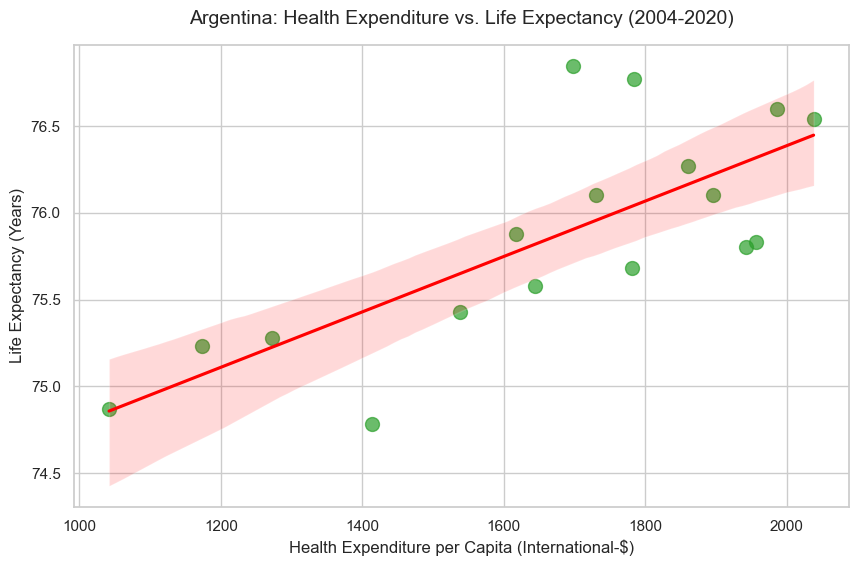

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to database and fetch Argentina data
conn = sqlite3.connect("../database/healthcare.db")
query = """
SELECT year, life_expectancy, health_expenditure
FROM health_metrics
WHERE country = 'Argentina' AND health_expenditure IS NOT NULL
ORDER BY year ASC;
"""
df = pd.read_sql_query(query, conn)
conn.close()

# Set up the plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create a scatter plot with a linear regression line
sns.regplot(
    data=df, 
    x="health_expenditure", 
    y="life_expectancy", 
    scatter_kws={"s": 100, "alpha": 0.7, "color": "#2ca02c"}, 
    line_kws={"color": "red"}
)

# Add titles and labels
plt.title("Argentina: Health Expenditure vs. Life Expectancy (2004-2020)", fontsize=14, pad=15)
plt.xlabel("Health Expenditure per Capita (International-$)", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

# Save the plot as an image in your project folder
plt.savefig("../argentina_health_trend.png", bbox_inches='tight')

# Display the plot
plt.show()